In [4]:
!pip install biopython pandas numpy matplotlib

In [5]:
from Bio import SeqIO

record = SeqIO.read("/NC_000913.3_reference.fasta", "fasta")

print(record.id)
print(record.description)
print(len(record.seq))
print(record.seq[:100])

NC_000913.3
NC_000913.3 Escherichia coli str. K-12 substr. MG1655, complete genome
4641652
AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGCTTCTGAACTGGTTACCTGCCGTGAGTAAAT


In [6]:
genome = str(record.seq).upper()

a = genome.count("A")
t = genome.count("T")
g = genome.count("G")
c = genome.count("C")
n = genome.count("N")

gc = ((g + c) / len(genome)) * 100

print("Genome length:", len(genome))
print("A:", a)
print("T:", t)
print("G:", g)
print("C:", c)
print("N:", n)
print("GC content:", round(gc, 2), "%")

Genome length: 4641652
A: 1142742
T: 1141382
G: 1177437
C: 1180091
N: 0
GC content: 50.79 %


In [7]:
print("Total bases counted:", a + t + g + c + n)

Total bases counted: 4641652


In [8]:
allowed = {"A", "T", "G", "C", "N"}

extra = set(genome) - allowed

print("Unexpected characters:", extra)

Unexpected characters: set()


In [9]:
from Bio.Seq import Seq

start = 1694260
end = 1696071

uidA_region = genome[start - 1:end]

print("Region length:", len(uidA_region))

Region length: 1812


In [10]:
uidA = str(Seq(uidA_region).reverse_complement())

print("uidA length:", len(uidA))
print("First 60 bases:")
print(uidA[:60])

print("\nLast 60 bases:")
print(uidA[-60:])

uidA length: 1812
First 60 bases:
ATGTTACGTCCTGTAGAAACCCCAACCCGTGAAATCAAAAAACTCGACGGCCTGTGGGCA

Last 60 bases:
CAAAAACGCTGGACTGGCATGAACTTCGGTGAAAAACCGCAGCAGGGAGGCAAACAATGA


In [11]:
uidA_gc = ((uidA.count("G") + uidA.count("C")) / len(uidA)) * 100

print("Length:", len(uidA))
print("GC content:", round(uidA_gc, 2), "%")
print("N bases:", uidA.count("N"))

Length: 1812
GC content: 52.26 %
N bases: 0


In [12]:
protein = Seq(uidA).translate()

print("Protein length:", len(protein))
print("First 30 amino acids:")
print(protein[:30])
print("Stop codons:", protein.count("*"))
print("Last 10 amino acids:")
print(protein[-10:])

Protein length: 604
First 30 amino acids:
MLRPVETPTREIKKLDGLWAFSLDRENCGI
Stop codons: 1
Last 10 amino acids:
EKPQQGGKQ*


In [13]:
print("DNA length:", len(uidA))
print("Number of codons:", len(uidA) // 3)
print("Translated length:", len(protein))
print("Stop codons:", protein.count("*"))
print("Ends with stop:", protein.endswith("*"))

DNA length: 1812
Number of codons: 604
Translated length: 604
Stop codons: 1
Ends with stop: True


In [14]:
from Bio.SeqRecord import SeqRecord

uidA_record = SeqRecord(
    Seq(uidA),
    id="uidA",
    description="E. coli K-12 MG1655 uidA gene"
)

SeqIO.write(uidA_record, "uidA_reference.fasta", "fasta")

print("uidA_reference.fasta saved")

uidA_reference.fasta saved


In [15]:
import os

print("Current folder:", os.getcwd())
print(os.listdir())

Current folder: /content
['.config', 'uidA_reference.fasta', 'sample_data']


In [16]:
from google.colab import files

files.download("uidA_reference.fasta")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
forward_primer = "TTGCAACTGGACAAGGCACTA"
reverse_primer = "GTTCTTTCGGCTTGTTGCCC"

print("Forward primer:", forward_primer)
print("Reverse primer:", reverse_primer)
print("Forward length:", len(forward_primer))
print("Reverse length:", len(reverse_primer))

Forward primer: TTGCAACTGGACAAGGCACTA
Reverse primer: GTTCTTTCGGCTTGTTGCCC
Forward length: 21
Reverse length: 20


In [18]:
forward_gc = ((forward_primer.count("G") + forward_primer.count("C")) / len(forward_primer)) * 100
reverse_gc = ((reverse_primer.count("G") + reverse_primer.count("C")) / len(reverse_primer)) * 100

print("Forward GC:", round(forward_gc, 2), "%")
print("Reverse GC:", round(reverse_gc, 2), "%")

Forward GC: 47.62 %
Reverse GC: 55.0 %


In [19]:
reverse_binding = str(Seq(reverse_primer).reverse_complement())

forward_pos = uidA.find(forward_primer)
reverse_pos = uidA.find(reverse_binding)

print("Forward primer starts at:", forward_pos + 1)
print("Reverse binding site starts at:", reverse_pos + 1)
print("Reverse binding sequence:", reverse_binding)

Forward primer starts at: 671
Reverse binding site starts at: 1101
Reverse binding sequence: GGGCAACAAGCCGAAAGAAC


In [20]:
amplicon = uidA[forward_pos:reverse_pos + len(reverse_binding)]

print("Amplicon length:", len(amplicon))
print("First 30 bases:", amplicon[:30])
print("Last 30 bases:", amplicon[-30:])

Amplicon length: 450
First 30 bases: TTGCAACTGGACAAGGCACTAGCGGGACTT
Last 30 bases: GTTTCGAAGCGGGCAACAAGCCGAAAGAAC


In [21]:
amplicon_record = SeqRecord(
    Seq(amplicon),
    id="uidA_amplicon",
    description="450 bp predicted PCR product"
)

SeqIO.write(amplicon_record, "uidA_amplicon.fasta", "fasta")

print("uidA_amplicon.fasta saved")

uidA_amplicon.fasta saved


In [22]:
from google.colab import files

files.download("uidA_amplicon.fasta")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
amplicon_gc = ((amplicon.count("G") + amplicon.count("C")) / len(amplicon)) * 100

print("Amplicon length:", len(amplicon))
print("GC content:", round(amplicon_gc, 2), "%")
print("A:", amplicon.count("A"))
print("T:", amplicon.count("T"))
print("G:", amplicon.count("G"))
print("C:", amplicon.count("C"))
print("N:", amplicon.count("N"))

Amplicon length: 450
GC content: 52.0 %
A: 110
T: 106
G: 124
C: 110
N: 0


In [24]:
print("Starts with forward primer:", amplicon.startswith(forward_primer))
print("Ends with reverse primer binding site:", amplicon.endswith(reverse_binding))

Starts with forward primer: True
Ends with reverse primer binding site: True


In [25]:
sanger_read = amplicon[:400]

print("Read length:", len(sanger_read))
print("First 30 bases:", sanger_read[:30])
print("Last 30 bases:", sanger_read[-30:])

Read length: 400
First 30 bases: TTGCAACTGGACAAGGCACTAGCGGGACTT
Last 30 bases: GGTGATTGATGAAACTGCTGCTGTCGGCTT


In [26]:
quality = []

for i in range(len(sanger_read)):
    if i < 20:
        quality.append(20)
    elif i > 370:
        quality.append(22)
    else:
        quality.append(35)

print("Number of quality scores:", len(quality))
print("First 30 scores:", quality[:30])
print("Last 30 scores:", quality[-30:])

Number of quality scores: 400
First 30 scores: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35]
Last 30 scores: [35, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]


In [27]:
average_quality = sum(quality) / len(quality)

q30_bases = 0

for score in quality:
    if score >= 30:
        q30_bases += 1

q30_percent = (q30_bases / len(quality)) * 100

print("Average quality:", round(average_quality, 2))
print("Bases with Q30 or higher:", q30_bases)
print("Q30 percentage:", round(q30_percent, 2), "%")

Average quality: 33.31
Bases with Q30 or higher: 351
Q30 percentage: 87.75 %


In [28]:
trimmed_read = sanger_read[20:371]
trimmed_quality = quality[20:371]

print("Original read length:", len(sanger_read))
print("Trimmed read length:", len(trimmed_read))
print("Bases removed:", len(sanger_read) - len(trimmed_read))
print("Lowest quality after trimming:", min(trimmed_quality))


Original read length: 400
Trimmed read length: 351
Bases removed: 49
Lowest quality after trimming: 35


In [29]:
reference_region = amplicon[20:371]

matches = 0

for i in range(len(trimmed_read)):
    if trimmed_read[i] == reference_region[i]:
        matches += 1

identity = (matches / len(trimmed_read)) * 100

print("Bases compared:", len(trimmed_read))
print("Matching bases:", matches)
print("Sequence identity:", round(identity, 2), "%")

Bases compared: 351
Matching bases: 351
Sequence identity: 100.0 %


In [30]:
mismatches = []

for i in range(len(trimmed_read)):
    if trimmed_read[i] != reference_region[i]:
        mismatches.append(i + 1)

print("Number of mismatches:", len(mismatches))
print("Mismatch positions:", mismatches)

Number of mismatches: 0
Mismatch positions: []


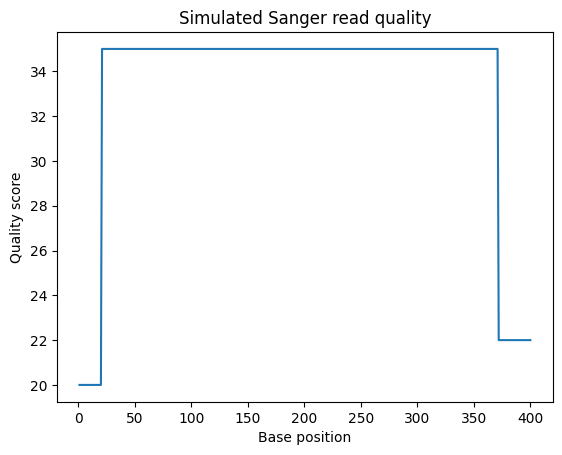

In [31]:
import matplotlib.pyplot as plt

positions = range(1, len(quality) + 1)

plt.plot(positions, quality)

plt.xlabel("Base position")
plt.ylabel("Quality score")
plt.title("Simulated Sanger read quality")

plt.show()

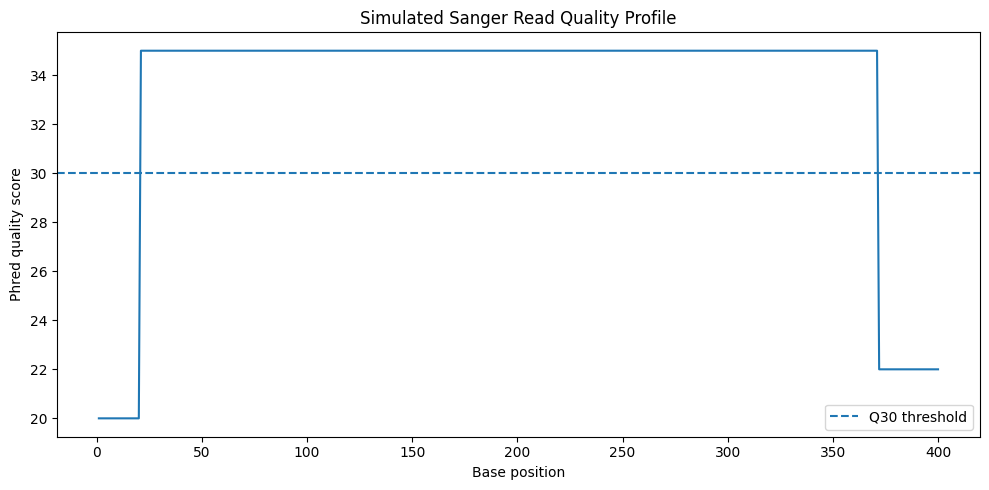

sanger_quality_profile.png saved


In [32]:
plt.figure(figsize=(10, 5))

plt.plot(positions, quality)

plt.xlabel("Base position")
plt.ylabel("Phred quality score")
plt.title("Simulated Sanger Read Quality Profile")

plt.axhline(y=30, linestyle="--", label="Q30 threshold")

plt.legend()
plt.tight_layout()

plt.savefig("sanger_quality_profile.png", dpi=300)
plt.show()

print("sanger_quality_profile.png saved")